# Notebook 02 — Preprocessing Pipeline & Baseline Models
**CSCI323 Modern Artificial Intelligence — Spring 2026**
**University of Wollongong Dubai (UOWD)**
**Member 2 — Preprocessing + Baseline Models**

This notebook loads the cleaned dataset, builds the preprocessing pipeline, and trains baseline models for both regression (Linear Regression) and classification (Logistic Regression).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to where you saved cleaned_data.csv
DATA_PATH = '/content/drive/MyDrive/CSCI323 - project dld transaction Data/cleaned_data.csv'

df = pd.read_csv(DATA_PATH)
df = df.sample(n=100000, random_state=42)
print(df.shape)
print(df.columns)
print(df.head())

Mounted at /content/drive
(100000, 16)
Index(['trans_group_en', 'property_type_en', 'property_sub_type_en',
       'property_usage_en', 'reg_type_en', 'area_name_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'rooms_en', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'year', 'month'],
      dtype='object')
       trans_group_en property_type_en property_sub_type_en property_usage_en  \
990023      Mortgages            Villa                Villa       Residential   
395261          Sales             Unit                 Flat       Residential   
731568          Sales             Unit                 Flat       Residential   
77194       Mortgages            Villa              Unknown       Residential   
463912      Mortgages             Unit               Office        Commercial   

                reg_type_en        area_name_en           nearest_landmark_en  \
990023  Existing Properties  Al Thanayah Fourth  Sports City 

In [3]:
numerical_cols = [
'procedure_area',
'meter_sale_price',
'has_parking',
'year',
'month'
]

In [4]:
categorical_cols = [
'property_type_en',
'property_sub_type_en',
'property_usage_en',
'area_name_en',
'reg_type_en',
'rooms_en',
'nearest_metro_en',
'nearest_mall_en',
'nearest_landmark_en',
'trans_group_en'
]

In [5]:
y_reg = df['actual_worth']
X_reg = df.drop(columns=['actual_worth'])

In [6]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
X_reg,
y_reg,
test_size=0.2,
random_state=42
)

In [7]:
preprocessor_reg = ColumnTransformer(
[
('cat',
OneHotEncoder(handle_unknown='ignore',
sparse_output=False),
categorical_cols),

('num',
StandardScaler(),
numerical_cols)
]
)

In [8]:
X_train_reg = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg = preprocessor_reg.transform(X_test_reg)

In [9]:
lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)

LinearRegression()

In [10]:
y_pred_reg = lr.predict(X_test_reg)

In [11]:
rmse = mean_squared_error(
y_test_reg,
y_pred_reg
)**0.5

mae = mean_absolute_error(
y_test_reg,
y_pred_reg
)

r2 = r2_score(
y_test_reg,
y_pred_reg
)

print("RMSE =",rmse)
print("MAE =",mae)
print("R2 =",r2)

RMSE = 10283692.800702792
MAE = 2736563.505903023
R2 = 0.28341841520841227


In [12]:
y_class = df['property_usage_en']
X_class = df.drop(
columns=['actual_worth','property_usage_en']
)

In [13]:
categorical_cols_class = [
'property_type_en',
'property_sub_type_en',
'area_name_en',
'reg_type_en',
'rooms_en',
'nearest_metro_en',
'nearest_mall_en',
'nearest_landmark_en',
'trans_group_en'
]

In [14]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
X_class,
y_class,
test_size=0.2,
random_state=42,
stratify=y_class
)

In [15]:
preprocessor_class = ColumnTransformer(
[
('cat',
OneHotEncoder(handle_unknown='ignore'),
categorical_cols_class),

('num',
StandardScaler(),
numerical_cols)
]
)

In [16]:
X_train_class = preprocessor_class.fit_transform(X_train_class)

X_test_class = preprocessor_class.transform(X_test_class)

In [17]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='saga'
)

log_model.fit(
    X_train_class,
    y_train_class
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, random_state=42, solver='saga')

In [18]:
y_pred_class = log_model.predict(
    X_test_class
)

In [19]:
print("Accuracy =")

print(
    accuracy_score(
        y_test_class,
        y_pred_class
    )
)

Accuracy =
0.9686


In [20]:
print("Precision =")

print(
    precision_score(
        y_test_class,
        y_pred_class,
        average=None
    )
)

Precision =
[0.90302398 0.83333333 0.98411116]


In [21]:
print("Recall =")

print(
    recall_score(
        y_test_class,
        y_pred_class,
        average=None
    )
)


Recall =
[0.89003083 0.77586207 0.99014866]


In [22]:
print("F1 Score =")

print(
    f1_score(
        y_test_class,
        y_pred_class,
        average=None
    )
)

F1 Score =
[0.89648033 0.80357143 0.98712068]


In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test_class, y_pred_class,
      target_names=['Commercial', 'Other', 'Residential']))

              precision    recall  f1-score   support

  Commercial       0.90      0.89      0.90      1946
       Other       0.83      0.78      0.80      1102
 Residential       0.98      0.99      0.99     16952

    accuracy                           0.97     20000
   macro avg       0.91      0.89      0.90     20000
weighted avg       0.97      0.97      0.97     20000



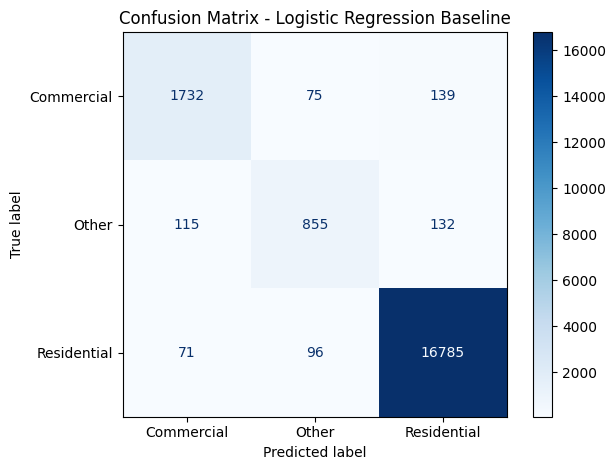

In [24]:
class_names = ['Commercial', 'Other', 'Residential']

cm = confusion_matrix(y_test_class, y_pred_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
joblib.dump(
    preprocessor_class,
    "preprocessing_pipeline.pkl"
)

['preprocessing_pipeline.pkl']